# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [35]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.data import get_contunious_data, get_discrete_data
from python.visualization import plot_fit_quantiles, plot_fit_cdf, plot_fit_copula, plot_fit_joint_contour

from python.tea import disco_tea

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [2]:
# Lade die originale R-Datei
result_rda = pyreadr.read_r('../data/dube.rda')
df_raw = result_rda['dube']

# Spalten passend für DiSCo umbenennen
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

Datensatz geladen: 652870 Zeilen


,time_col,id_col,y_col
0,1998.0,1.0,2.791217
1,1998.0,1.0,0.165951
2,1998.0,1.0,1.674730
3,1998.0,1.0,2.088006
4,1998.0,1.0,3.639715


In [ ]:
print("Initialisiere DiSCo mit Dube-Daten...")  
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=100,              # Grid Size
    num_cores=-2,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9,            # Entspricht den Parametern in der Vignette
    CI=True,             # Bootstrap-Konfidenzintervalle berechnen
    cl=0.95,             # Konfidenzniveau für Intervalle
    uniform=False,
    perm=True,
    mixture=False
)

result = disco_model.fit()

Initialisiere DiSCo mit Dube-Daten...


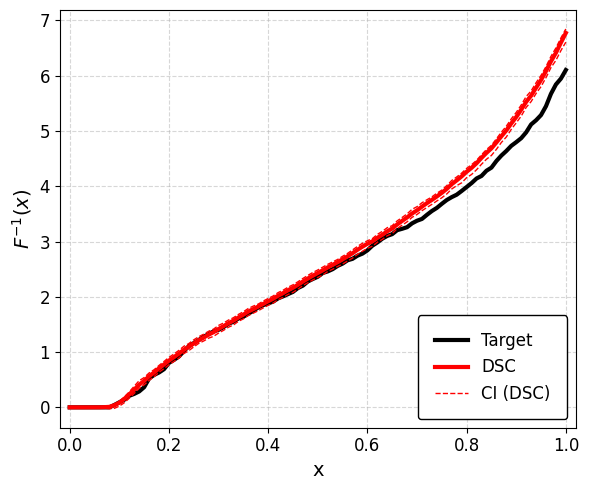

In [4]:
plot_fit_quantiles(result, show_controls=False)

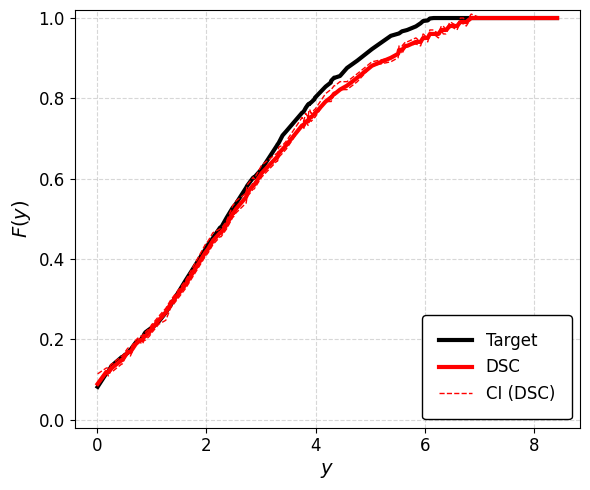

In [5]:
plot_fit_cdf(result, show_controls=False)

In [6]:
pd.Series(result.weights, index=disco_model.controls_id).sort_values(ascending=False).head(5)

39.0    0.162124
29.0    0.139123
45.0    0.089634
26.0    0.076657
19.0    0.068560
dtype: float64


Call:
DiSCoTEA

--- Treatment Effects ---
 Time  X_from  X_to  Quantile Delta  Std. Error   [95%   Conf. Band] Sig
 2003     0.0   0.9         -0.0512       0.044 -0.1253       0.0555    
 2004     0.0   0.9         -0.1517       0.045 -0.2496      -0.0763   *

--- Permutation Test ---
p-value: 0.2059

None


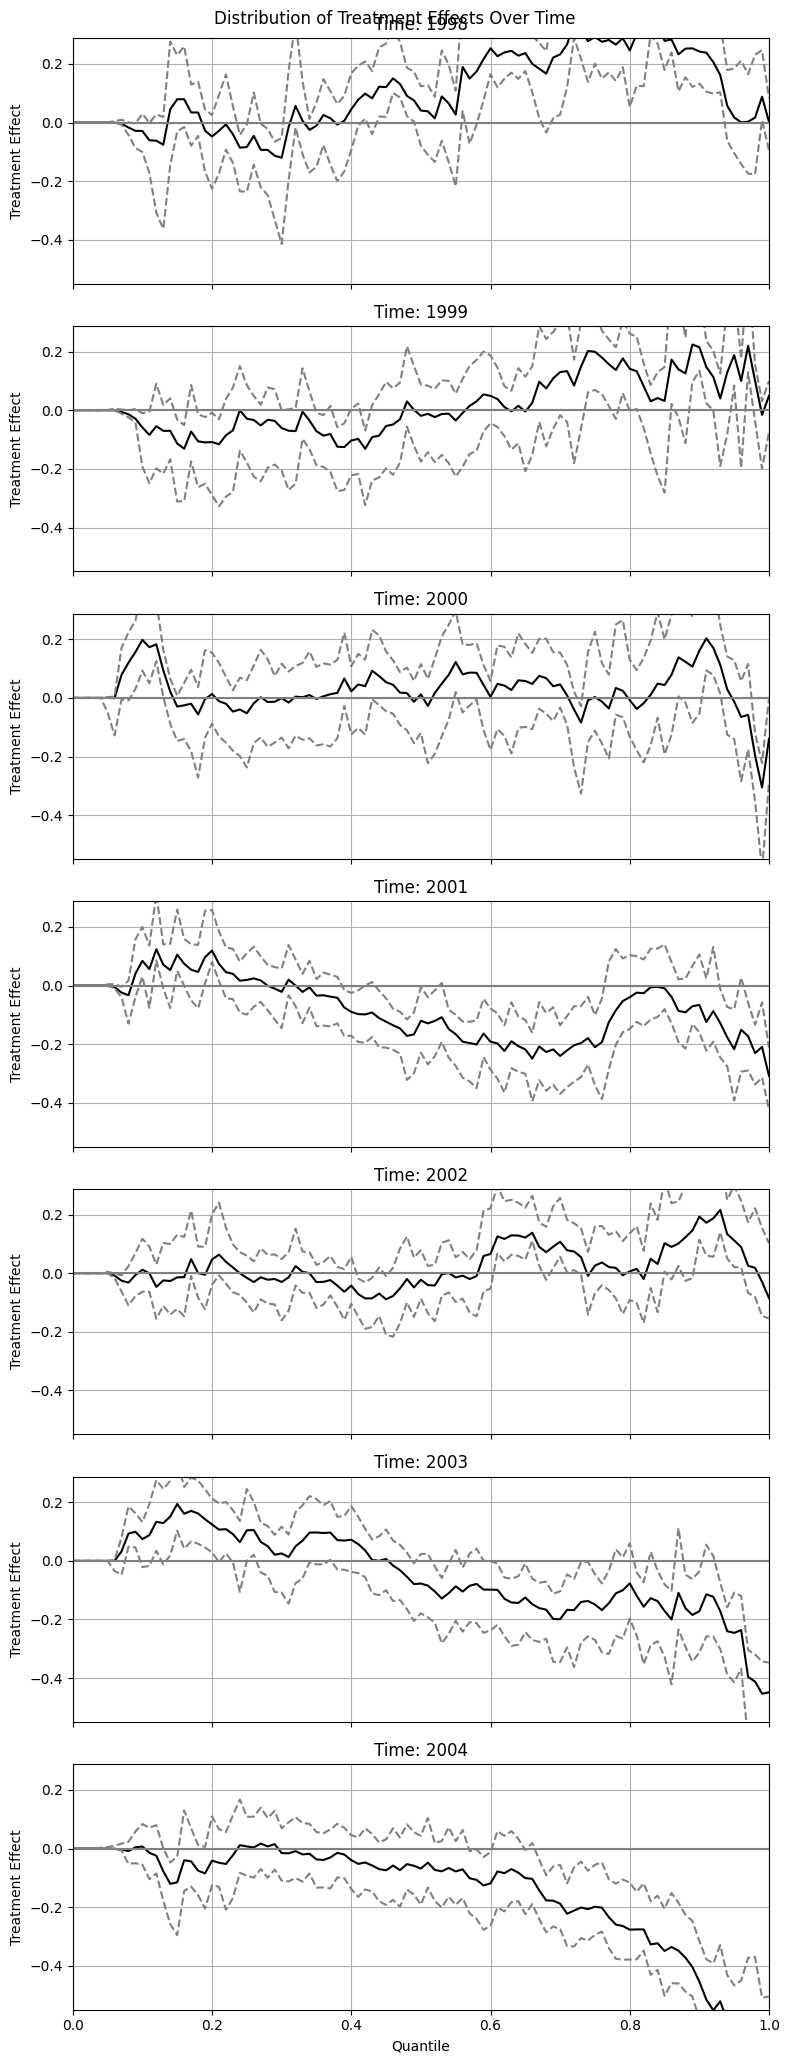

In [7]:
from python.tea import disco_tea
tea_res = disco_tea(result, agg="quantileDiff", graph=True )
print(tea_res.summary())

## Paper replication

### Simulated Data

In [36]:
# Recreation of figure 4 from DiSCo paper
num_controls = 4
sample_size = 1000
seed = 42
synth_df = get_contunious_data(sample_size, num_controls, target_offset=0, dist_control=3, dist_target=4)

fit_synth = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)
fit_synth = fit_synth.fit()


c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:116: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=100000, eps=1e-6)


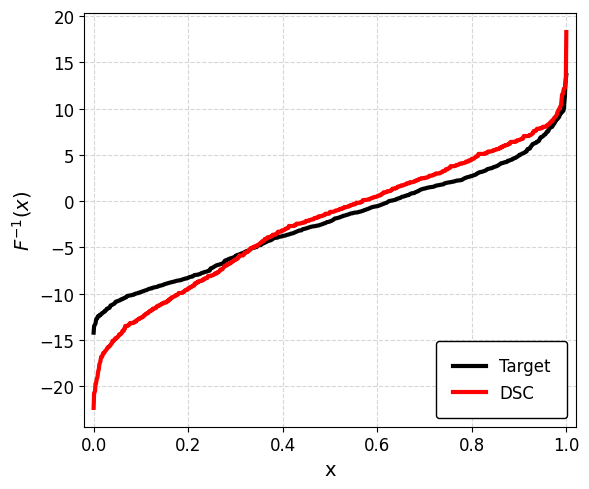

In [5]:
# Get the post-treatment period result to see how it fitted
plot_fit_quantiles(fit_synth, show_controls=False)

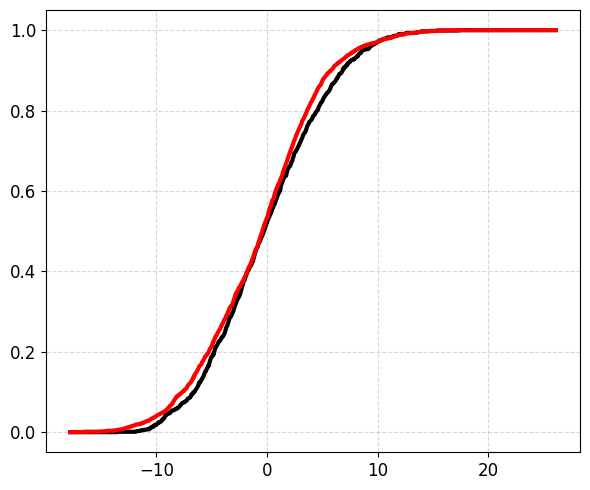

In [3]:
plot_fit_cdf(fit_synth, show_controls=False)

In [11]:
synth_df = get_discrete_data(sample_size, num_controls)

fit_synth_disc = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
)
fit_synth_disc = fit_synth_disc.fit()

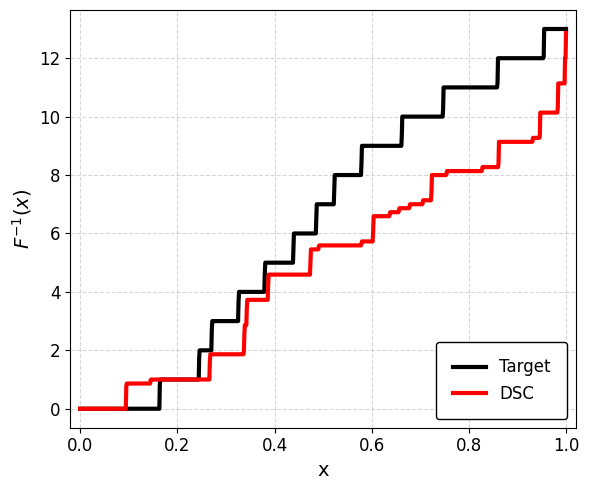

25.0000% der Kontrollen haben ein Gewicht > 1e-4


In [12]:
# Get the post-treatment period result to see how it fitted
period_res = fit_synth_disc.results_periods[2.0]  # The post-treatment period
plot_fit_quantiles(fit_synth_disc, show_controls=False)
weights = period_res.DiSCo.weights
print(f'{(sum(weights > 1e-4)/len(weights))*100:.4f}% der Kontrollen haben ein Gewicht > 1e-4')

### Dube Daten aus 2013

In [14]:
dube = pd.read_csv('../dube_full_data/dube_combined.csv')
dube_2013 = dube[dube['year'] == 2013].copy()
dube_2013 = dube_2013.dropna(subset=['faminc', 'age']) # NA werte handhaben

data = []
for fips, group in dube_2013.groupby('fips'):
    if len(group) < 2000:
        continue # Ignoriere die kleinen states
    group = group.sample(n=2000, random_state=42) # Shuffle und 2000 ziehen
    
    # Pre-treatment (Jahr 1)
    pre = group.iloc[:1000].copy()
    pre['year'] = 1
    
    # Post-treatment (Jahr 2)
    post = group.iloc[1000:].copy()
    post['year'] = 2
    
    data.extend([pre, post])

dube_multi = pd.concat(data, ignore_index=True)
print(f"Number of valid states: {dube_multi['fips'].nunique()}")

Number of valid states: 51


In [15]:
fit_dube_multi = DiSCo(
    df=dube_multi,
    id_col='fips',
    time_col='year',
    y_col=['faminc', 'age'],
    id_col_target=4,       # FIPS = 4 (Beispiel state) als Treatment
    t0=2,                  # Treatment im Jahr 2 (post-treatment)
    M=1000,                # Monte Carlo Draws 
    G=50,                  # Grid Size (Kleiner für multidimensional)
    num_cores=-1,          # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,          # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=42,
    mixture=True
)
fit_dube_multi = fit_dube_multi.fit()

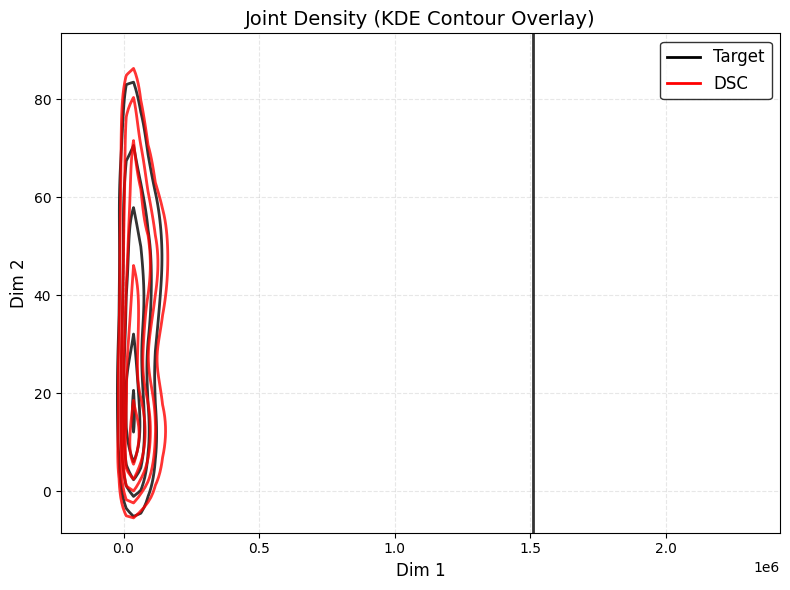

In [16]:
plot_fit_joint_contour(fit_dube_multi)

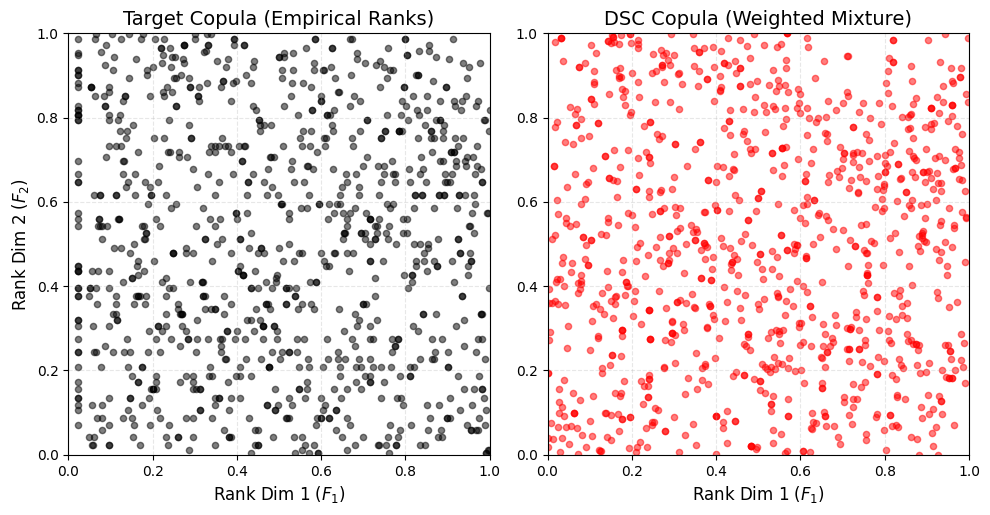

In [17]:
plot_fit_copula(fit_dube_multi)

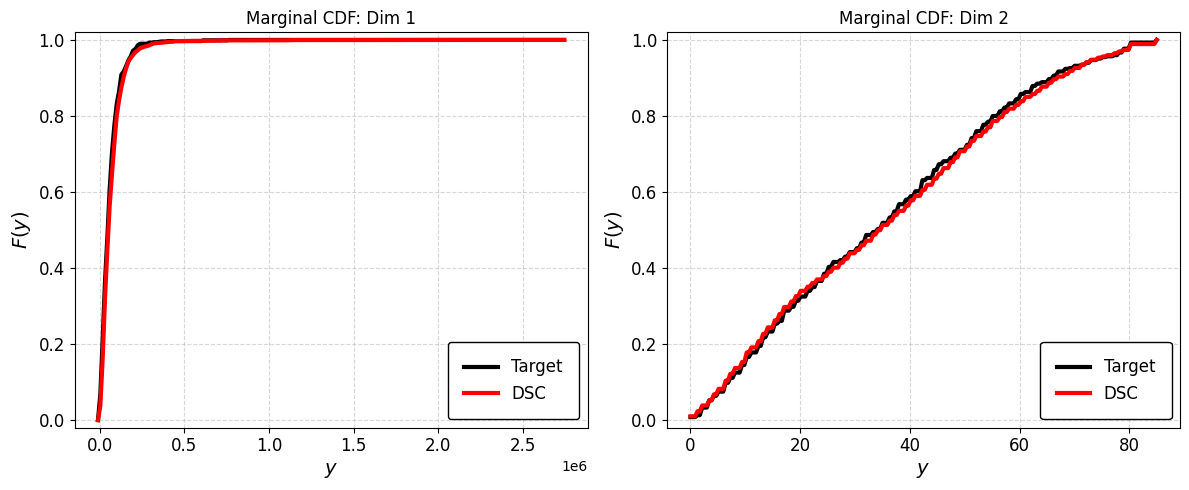

In [18]:
plot_fit_cdf(fit_dube_multi)

In [36]:
fit_dube_multi_tea = disco_tea(fit_dube_multi, graph=True)
print(fit_dube_multi_tea.summary())

KeyError: 'time_col'

In [19]:
# Super realistische Schwankungen (nahe der vorgegebenen Baseline)
test_df = get_contunious_data(1000, 10, dim=2, base_corr=0.3, corr_drift=0.6)

print(test_df[test_df['time_col'] == 9999].groupby('id_col').apply(lambda x: np.corrcoef(x['y_col_1'], x['y_col_2'])[0, 1]))
print(np.corrcoef(test_df.loc[test_df['time_col'] == 9999, ['y_col_1', 'y_col_2']].values.T)[0,1])

id_col
0     0.005873
1     0.804611
10    0.049660
2     0.523007
3     0.170180
4     0.298979
5     0.644490
6     0.124835
7     0.184972
8    -0.035784
9     0.331842
dtype: float64
0.2044125530171661


In [20]:
fit_2D = DiSCo(
    df=test_df,
    id_col='id_col',
    time_col='time_col',
    y_col=['y_col_1','y_col_2'],
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)
fit_2D = fit_2D.fit()

c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:116: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=100000, eps=1e-6)


In [26]:
pd.Series(fit_2D.results_periods[1].DiSCo.weights, index=fit_2D.control_ids).sort_values(ascending=False).head(5)

4    0.755193
9    0.191865
6    0.052941
7    0.000006
5    0.000003
dtype: float64

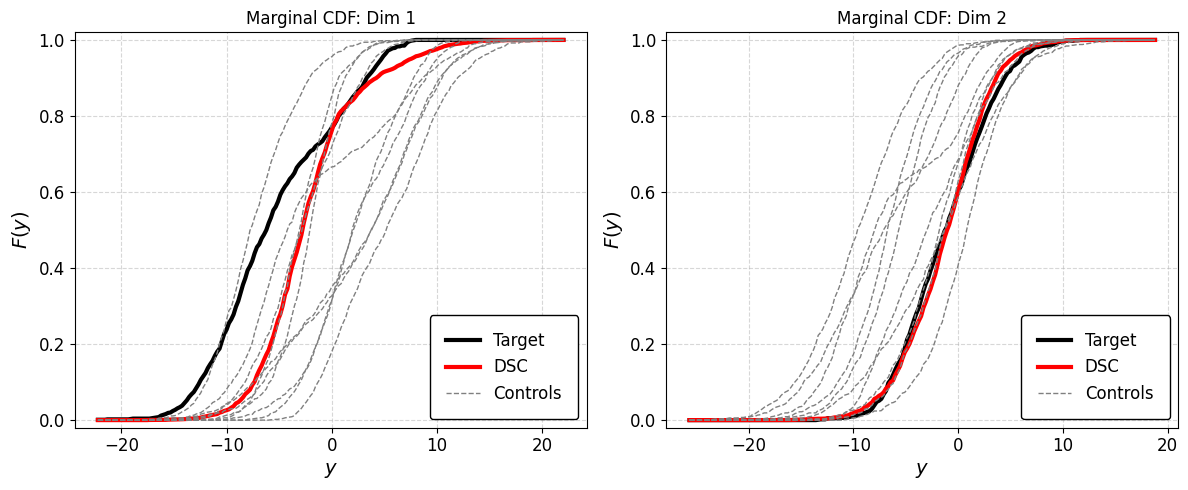

In [27]:
plot_fit_cdf(fit_2D, show_controls=True)

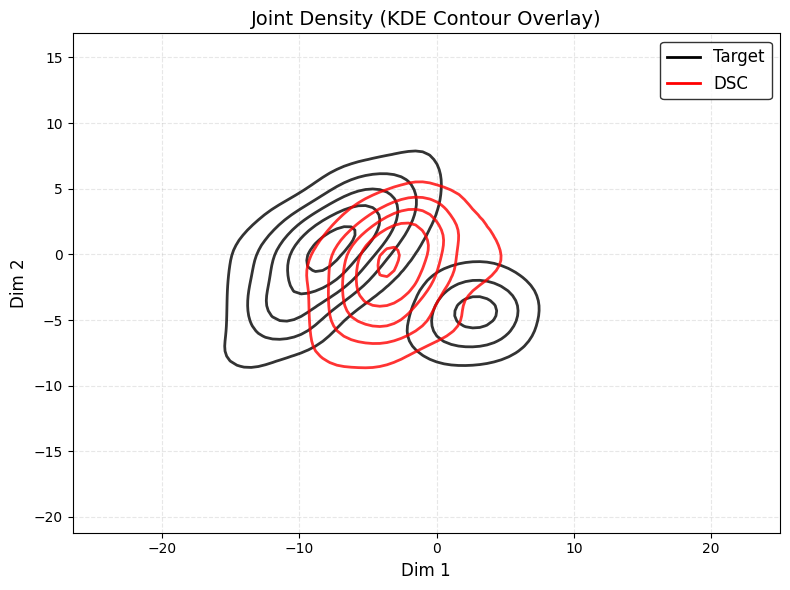

In [32]:
plot_fit_joint_contour(fit_2D)

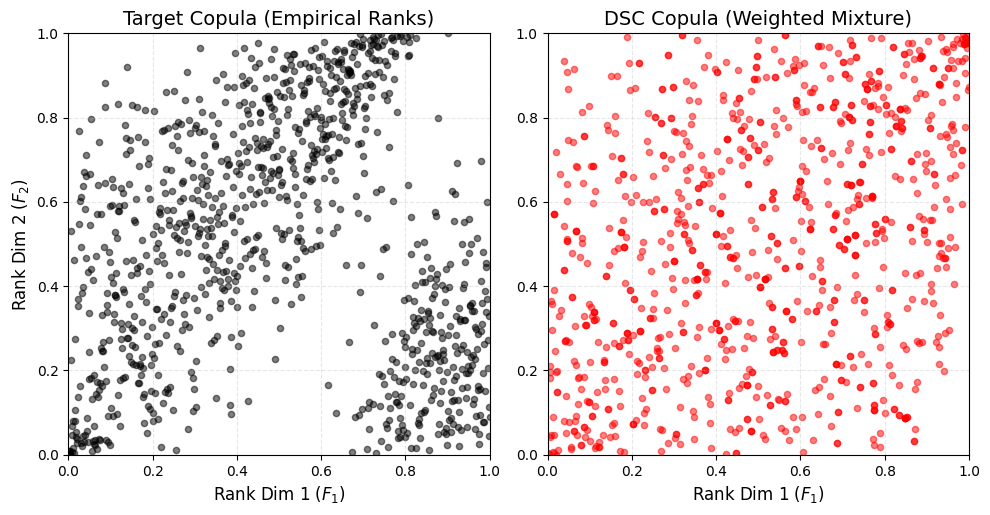

In [29]:
plot_fit_copula(fit_2D)

In [30]:
plot_fit_joint_cdf(fit_2D)

NameError: name 'plot_fit_joint_cdf' is not defined